# Projeto Final de PCP - Planejamento Agregado da Producao

**Disciplina:** Planejamento e Controle da Producao (EPR/FT/UnB)
**Autor:** _(preencher)_

**Tema (eixo central):** Planejamento Agregado da Producao por Programacao Linear.
**Integracoes:** Previsao de Demanda + Gestao de Estoque / Nivel de Servico.

Este notebook e o pipeline ponta a ponta. Nesta Fase 1 ele ja roda do inicio ao
fim de forma reproduzivel (demanda -> previsao -> plano -> decisao). As fases
seguintes aprofundam previsao (Holt-Winters/SARIMA), cenarios, sensibilidade e
Monte Carlo. Premissas e calibracao em `docs/00_premissas.md`.

## 0. Configuracao e reprodutibilidade

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Localiza a pasta src/ rode-se o notebook de projeto_final/ ou de notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import config, parametros, modelo  # noqa: E402
from config import SEED, get_rng
from parametros import (demanda_esperada, demanda_simulada,
                        CUSTOS, CAPACIDADE, HORIZONTE_MESES, NIVEL_SERVICO_ALVO)
from modelo import resolve_pap

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
print(f'SEED = {SEED} | horizonte = {HORIZONTE_MESES} meses | '
      f'nivel de servico alvo = {NIVEL_SERVICO_ALVO:.0%}')

SEED = 42 | horizonte = 12 meses | nivel de servico alvo = 95%


## 1. Demanda

Serie sazonal de um fabricante de ventiladores: vale no mes 1 (baixa estacao) e
pico no mes 7 (verao). A serie esperada e deterministica; a simulada adiciona
ruido multiplicativo Normal (CV = 8%), reprodutivel pela semente.

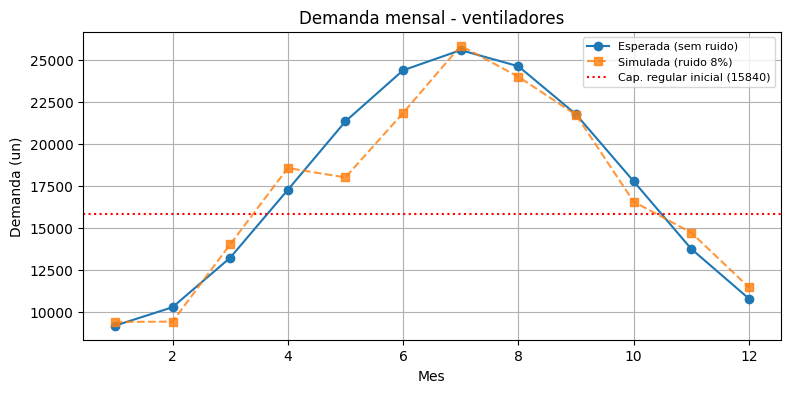

,mes,demanda_esperada,demanda_simulada
0,1,9180.0,9403.8
1,2,10278.8,9423.6
2,3,13220.9,14014.6
3,4,17255.0,18553.4
4,5,21328.2,17999.2
5,6,24366.6,21828.2
6,7,25564.6,25826.1
7,8,24604.3,23981.9
8,9,21746.4,21717.2
9,10,17765.0,16552.7


In [2]:
meses = np.arange(1, HORIZONTE_MESES + 1)
D_esp = demanda_esperada()
rng = get_rng()
D_sim = demanda_simulada(rng)

df_dem = pd.DataFrame({'mes': meses,
                       'demanda_esperada': np.round(D_esp, 1),
                       'demanda_simulada': np.round(D_sim, 1)})

# salva os dados gerados (reprodutibilidade - criterio C3)
(ROOT / 'data' / 'raw').mkdir(parents=True, exist_ok=True)
df_dem.to_csv(ROOT / 'data' / 'raw' / 'demanda.csv', index=False)

cap_reg = CAPACIDADE['produtividade_por_trab_mes'] * CAPACIDADE['trabalhadores_inicial']
fig, ax = plt.subplots()
ax.plot(meses, D_esp, 'o-', label='Esperada (sem ruido)')
ax.plot(meses, D_sim, 's--', alpha=0.8, label='Simulada (ruido 8%)')
ax.axhline(cap_reg, color='r', ls=':', label=f'Cap. regular inicial ({cap_reg:.0f})')
ax.set(xlabel='Mes', ylabel='Demanda (un)', title='Demanda mensal - ventiladores')
ax.legend(fontsize=8)
plt.show()
df_dem

## 2. Previsao (versao minima)

Baseline ingenuo (media movel de 3 meses) apenas para fechar o pipeline. A Fase 2
substitui por Holt-Winters e SARIMA, com backtest e escolha do melhor modelo.

In [3]:
serie = pd.Series(D_sim, index=meses)
prev_mm = serie.rolling(3).mean().shift(1)
erro = (serie - prev_mm).dropna()
mae = erro.abs().mean()
rmse = float((erro ** 2).mean() ** 0.5)
mape = (erro.abs() / serie.loc[erro.index]).mean() * 100
print(f'Media movel(3)  ->  MAE = {mae:,.0f} un | RMSE = {rmse:,.0f} un | MAPE = {mape:.1f}%')
print('Baseline ingenuo; a Fase 2 traz Holt-Winters/SARIMA e a escolha formal do modelo.')

Media movel(3)  ->  MAE = 5,192 un | RMSE = 5,540 un | MAPE = 29.8%
Baseline ingenuo; a Fase 2 traz Holt-Winters/SARIMA e a escolha formal do modelo.


## 3. Planejamento agregado (plano misto)

Resolve o PL de custo-relevante (`src/modelo.py`) sobre a demanda esperada.

In [4]:
res = resolve_pap(D_esp, 'misto')
print(f'Status: {res.status} | Custo total relevante: R$ {res.custo_total:,.0f}')

plano = pd.DataFrame(res.plano, index=meses).rename(columns={
    'W': 'trabalhadores', 'P': 'prod_regular', 'O': 'hora_extra',
    'I': 'estoque', 'B': 'atraso', 'H': 'contrata', 'F': 'demite'})
plano.insert(0, 'demanda', np.round(D_esp).astype(int))
plano[['demanda', 'trabalhadores', 'prod_regular', 'hora_extra', 'estoque', 'atraso']]

Status: Optimal | Custo total relevante: R$ 4,915,334


,demanda,trabalhadores,prod_regular,hora_extra,estoque,atraso
1,9180,88.0,13999.296,0.0,6819.296,0.0
2,10279,88.0,15840.000,0.0,12380.476,0.0
3,13221,92.0,16560.000,0.0,15719.576,0.0
4,17255,96.0,17280.000,0.0,15744.576,0.0
5,21328,100.0,18000.000,0.0,12416.376,0.0
6,24367,104.0,18720.000,2246.4,9016.150,0.0
7,25565,104.0,18720.000,2246.4,4417.950,0.0
8,24604,104.0,18720.000,2246.4,780.000,0.0
9,21746,104.0,18720.000,2246.4,0.000,0.0
10,17765,100.0,17765.000,0.0,0.000,0.0


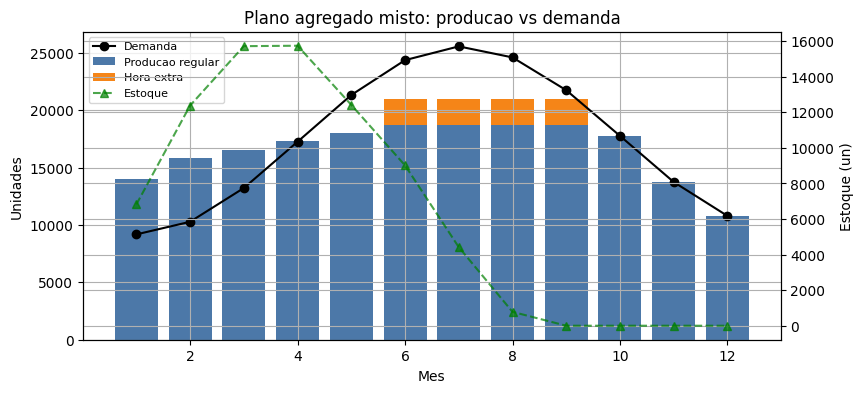

In [5]:
fig, ax1 = plt.subplots()
ax1.bar(meses, plano['prod_regular'], color='#4C78A8', label='Producao regular')
ax1.bar(meses, plano['hora_extra'], bottom=plano['prod_regular'],
        color='#F58518', label='Hora extra')
ax1.plot(meses, plano['demanda'], 'k-o', label='Demanda')
ax1.set(xlabel='Mes', ylabel='Unidades',
        title='Plano agregado misto: producao vs demanda')
ax2 = ax1.twinx()
ax2.plot(meses, plano['estoque'], 'g--^', alpha=0.7, label='Estoque')
ax2.set_ylabel('Estoque (un)')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
plt.show()

## 4. Decisao (preliminar)

Compara as tres estrategias e conclui com uma recomendacao. A Fase 4 formaliza os
cenarios e a Fase 5 traz sensibilidade e Monte Carlo (erro de previsao ->
custo/servico).

In [6]:
comp = {modo: resolve_pap(D_esp, modo).custo_total
        for modo in ('misto', 'nivel', 'perseguicao')}
base = comp['misto']
tab = (pd.DataFrame({'custo_total': comp})
       .assign(gap_vs_misto=lambda d: (d['custo_total'] / base - 1) * 100))
print(tab.to_string(formatters={'custo_total': 'R$ {:,.0f}'.format,
                                'gap_vs_misto': '{:+.1f}%'.format}))

g_niv = (comp['nivel'] / base - 1) * 100
g_per = (comp['perseguicao'] / base - 1) * 100
print(f'\nDECISAO (preliminar): adotar o plano MISTO (R$ {base:,.0f}).')
print(f'  - Nivel custa {g_niv:+.1f}% (excesso de estoque na baixa estacao).')
print(f'  - Perseguicao custa {g_per:+.1f}% (contratacao/demissao + atraso no pico).')

             custo_total gap_vs_misto
misto       R$ 4,915,334        +0.0%
nivel       R$ 5,170,426        +5.2%
perseguicao R$ 5,661,200       +15.2%

DECISAO (preliminar): adotar o plano MISTO (R$ 4,915,334).
  - Nivel custa +5.2% (excesso de estoque na baixa estacao).
  - Perseguicao custa +15.2% (contratacao/demissao + atraso no pico).
